# Pollution Risk Forecasting & Air Quality Intelligence
### Predicting PM2.5 concentration using Random Forest, Gradient Boosting and XGBoost

**Goal:** Given readings of other pollutants and weather conditions, predict PM2.5 (fine particulate matter),
which is the main driver of air pollution risk. The predicted PM2.5 is then converted into a risk category
(Good / Moderate / Poor / Severe).

**Dataset:** `air_quality_dataset.csv` (500 records, no missing values)


## Phase 1: Import libraries

Basic libraries for data handling, plotting, and modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# just to keep plots looking decent
sns.set_style("whitegrid")


## Phase 2: Load & inspect the data


In [2]:
df = pd.read_csv("air_quality_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (500, 14)


,PM2.5,PM10,NOx,NO2,SO2,VOCs,CO,CO2,CH4,Temperature,Humidity,Wind_Direction,Location_Type,Source_Label
0,39.967142,57.926035,116.192213,55.230299,4.531693,75.317261,2.789606,427.674347,1.706105,31.085120,45.454749,276,Urban,Vehicular
1,101.935672,150.774299,76.826826,79.051618,18.744780,145.083987,1.966569,529.739619,2.492663,33.711103,60.798212,134,Industrial,Industrial
2,70.996192,138.948796,158.731020,60.466604,14.892239,145.147338,2.626446,499.889443,2.431165,33.778698,54.875669,1,Industrial,Industrial
3,28.464728,63.643900,25.385343,15.333286,7.647429,130.022319,1.779360,388.283712,1.818563,31.565877,67.113319,251,Rural,Biomass Burning
4,78.265276,113.977926,105.644340,59.202337,17.696806,181.713667,3.240533,464.739197,2.597225,32.229835,37.236519,326,Industrial,Industrial


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PM2.5           500 non-null    float64
 1   PM10            500 non-null    float64
 2   NOx             500 non-null    float64
 3   NO2             500 non-null    float64
 4   SO2             500 non-null    float64
 5   VOCs            500 non-null    float64
 6   CO              500 non-null    float64
 7   CO2             500 non-null    float64
 8   CH4             500 non-null    float64
 9   Temperature     500 non-null    float64
 10  Humidity        500 non-null    float64
 11  Wind_Direction  500 non-null    int64  
 12  Location_Type   500 non-null    str    
 13  Source_Label    500 non-null    str    
dtypes: float64(11), int64(1), str(2)
memory usage: 54.8 KB


In [4]:
# check for missing values
df.isnull().sum()

PM2.5             0
PM10              0
NOx               0
NO2               0
SO2               0
VOCs              0
CO                0
CO2               0
CH4               0
Temperature       0
Humidity          0
Wind_Direction    0
Location_Type     0
Source_Label      0
dtype: int64

In [5]:
# summary statistics - useful to spot weird values (like negatives where they shouldn't exist)
df.describe()


,PM2.5,PM10,NOx,NO2,SO2,VOCs,CO,CO2,CH4,Temperature,Humidity,Wind_Direction
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,54.671620,84.703251,91.814080,42.410820,11.504816,112.193098,2.177705,439.288087,2.130439,30.448413,56.196914,180.842000
std,22.799473,30.567912,54.808414,26.343669,7.306978,39.471686,0.824762,51.220578,0.391396,2.957290,11.035563,102.323767
min,10.757597,12.932337,-0.076323,-1.942140,-1.095555,27.555617,0.366992,366.063158,1.388407,19.581349,35.077851,0.000000
25%,36.372940,61.118607,35.457263,17.448632,5.976492,81.516729,1.536915,397.399610,1.837395,28.481974,47.254489,95.750000
50%,48.038599,78.135558,95.452284,39.211583,8.681222,104.819124,2.045519,420.934319,2.066709,30.432756,55.816773,183.000000
75%,73.820566,110.270086,134.709240,63.817763,17.116673,140.588100,2.726020,490.968315,2.386267,32.614954,64.022677,267.000000
max,127.616632,171.594187,225.886935,115.916428,31.941860,231.926017,4.798935,558.924257,3.352266,39.778713,79.991414,359.000000


## Phase 3: Data cleaning

Two issues found during inspection:

1. `Source_Label` turned out to be basically a duplicate of `Location_Type`
2. `NOx`, `NO2`, `SO2` have a few negative values, which isn't physically possible for a pollutant
   concentration.


In [6]:
# drop redundant column
df = df.drop(columns=["Source_Label"])

# fix impossible negative concentration values
for col in ["NOx", "NO2", "SO2"]:
    df[col] = df[col].clip(lower=0)

df.describe()

,PM2.5,PM10,NOx,NO2,SO2,VOCs,CO,CO2,CH4,Temperature,Humidity,Wind_Direction
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,54.671620,84.703251,91.814232,42.414705,11.507662,112.193098,2.177705,439.288087,2.130439,30.448413,56.196914,180.842000
std,22.799473,30.567912,54.808158,26.337258,7.302307,39.471686,0.824762,51.220578,0.391396,2.957290,11.035563,102.323767
min,10.757597,12.932337,0.000000,0.000000,0.000000,27.555617,0.366992,366.063158,1.388407,19.581349,35.077851,0.000000
25%,36.372940,61.118607,35.457263,17.448632,5.976492,81.516729,1.536915,397.399610,1.837395,28.481974,47.254489,95.750000
50%,48.038599,78.135558,95.452284,39.211583,8.681222,104.819124,2.045519,420.934319,2.066709,30.432756,55.816773,183.000000
75%,73.820566,110.270086,134.709240,63.817763,17.116673,140.588100,2.726020,490.968315,2.386267,32.614954,64.022677,267.000000
max,127.616632,171.594187,225.886935,115.916428,31.941860,231.926017,4.798935,558.924257,3.352266,39.778713,79.991414,359.000000


## Phase 4: Encode the categorical column

`Location_Type` (Urban / Industrial / Rural) is text, so it needs to be converted into numeric
columns before it can be used by the models. One-hot encoding creates a separate 0/1 column for
each category.

In [7]:
df = pd.get_dummies(df, columns=["Location_Type"], drop_first=True)
df.head()

,PM2.5,PM10,NOx,NO2,SO2,VOCs,CO,CO2,CH4,Temperature,Humidity,Wind_Direction,Location_Type_Rural,Location_Type_Urban
0,39.967142,57.926035,116.192213,55.230299,4.531693,75.317261,2.789606,427.674347,1.706105,31.085120,45.454749,276,False,True
1,101.935672,150.774299,76.826826,79.051618,18.744780,145.083987,1.966569,529.739619,2.492663,33.711103,60.798212,134,False,False
2,70.996192,138.948796,158.731020,60.466604,14.892239,145.147338,2.626446,499.889443,2.431165,33.778698,54.875669,1,False,False
3,28.464728,63.643900,25.385343,15.333286,7.647429,130.022319,1.779360,388.283712,1.818563,31.565877,67.113319,251,True,False
4,78.265276,113.977926,105.644340,59.202337,17.696806,181.713667,3.240533,464.739197,2.597225,32.229835,37.236519,326,False,False


## Phase 5: Exploratory Data Analysis (EDA)

Before modeling, it helps to visually understand the data - the distribution of the target,
which features correlate with it, and whether the relationships look linear or not.

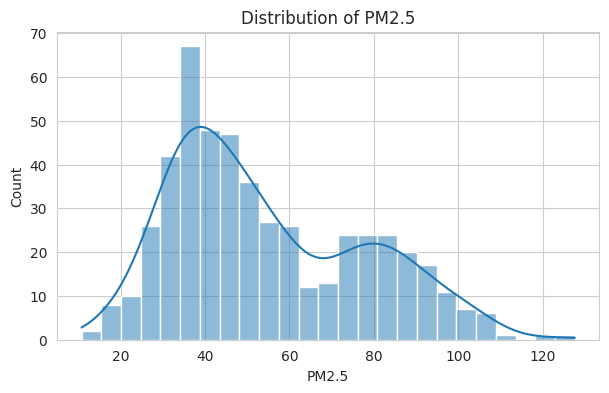

In [8]:
# distribution of the target variable
plt.figure(figsize=(7,4))
sns.histplot(df["PM2.5"], kde=True, bins=25)
plt.title("Distribution of PM2.5")
plt.show()

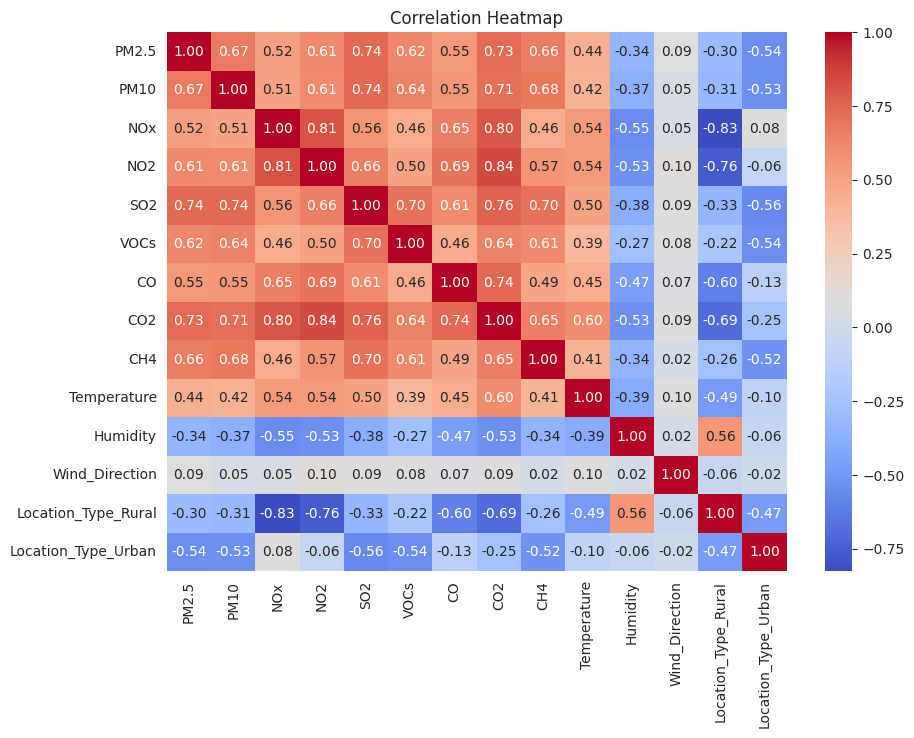

In [9]:
# correlation heatmap
plt.figure(figsize=(10,7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [10]:
# which features correlate most with PM2.5?
corr["PM2.5"].sort_values(ascending=False)

PM2.5                  1.000000
SO2                    0.740400
CO2                    0.731254
PM10                   0.670495
CH4                    0.663501
VOCs                   0.620937
NO2                    0.610082
CO                     0.549673
NOx                    0.516671
Temperature            0.443328
Wind_Direction         0.085189
Location_Type_Rural   -0.301865
Humidity              -0.336846
Location_Type_Urban   -0.538821
Name: PM2.5, dtype: float64

## Phase 6: Feature engineering

`Wind_Direction` is given in degrees (0-359), which is a circular value - 359° and 1° are
actually right next to each other, but as plain numbers they look far apart. Converting it into
sine and cosine components fixes this.

In [11]:
df["Wind_dir_sin"] = np.sin(np.deg2rad(df["Wind_Direction"]))
df["Wind_dir_cos"] = np.cos(np.deg2rad(df["Wind_Direction"]))
df = df.drop(columns=["Wind_Direction"])

df.head()

,PM2.5,PM10,NOx,NO2,SO2,VOCs,CO,CO2,CH4,Temperature,Humidity,Location_Type_Rural,Location_Type_Urban,Wind_dir_sin,Wind_dir_cos
0,39.967142,57.926035,116.192213,55.230299,4.531693,75.317261,2.789606,427.674347,1.706105,31.085120,45.454749,False,True,-0.994522,0.104528
1,101.935672,150.774299,76.826826,79.051618,18.744780,145.083987,1.966569,529.739619,2.492663,33.711103,60.798212,False,False,0.719340,-0.694658
2,70.996192,138.948796,158.731020,60.466604,14.892239,145.147338,2.626446,499.889443,2.431165,33.778698,54.875669,False,False,0.017452,0.999848
3,28.464728,63.643900,25.385343,15.333286,7.647429,130.022319,1.779360,388.283712,1.818563,31.565877,67.113319,True,False,-0.945519,-0.325568
4,78.265276,113.977926,105.644340,59.202337,17.696806,181.713667,3.240533,464.739197,2.597225,32.229835,37.236519,False,False,-0.559193,0.829038


## Phase 7: Training the data


In [12]:
X = df.drop(columns=["PM2.5"])
y = df["PM2.5"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (400, 14)
Test size: (100, 14)


## Phase 8: Baseline model - Linear Regression

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print(f"Linear Regression -> RMSE: {lr_rmse:.2f}, MAE: {lr_mae:.2f}, R2: {lr_r2:.3f}")

Linear Regression -> RMSE: 13.40, MAE: 10.13, R2: 0.683


## Phase 9: Train the three required models

Random Forest, Gradient Boosting, and XGBoost.

In [14]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

In [15]:
gbr = GradientBoostingRegressor(n_estimators=200, random_state=42)
gbr.fit(X_train, y_train)
gbr_preds = gbr.predict(X_test)

In [16]:
xgb = XGBRegressor(n_estimators=200, random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)


## Phase 10: Compare all models

A small helper function to compute RMSE, MAE and R2 for a set of predictions, then a results
table comparing every model trained so far.

In [17]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

results = [
    evaluate("Linear Regression", y_test, lr_preds),
    evaluate("Random Forest", y_test, rf_preds),
    evaluate("Gradient Boosting", y_test, gbr_preds),
    evaluate("XGBoost", y_test, xgb_preds),
]

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df


,Model,RMSE,MAE,R2
0,Linear Regression,13.395441,10.130978,0.683124
2,Gradient Boosting,13.598502,10.891224,0.673444
1,Random Forest,13.852319,10.977827,0.661140
3,XGBoost,14.527482,11.257716,0.627303


## Phase 11: Pick the best model for interpretation

No hyperparameter tuning here - just using the three models as trained in Phase 9, with default
settings. To decide which one to use for feature importance and risk classification, the model
with the lowest RMSE from the comparison table above (Phase 10) is picked automatically.

In [18]:
# only look at the three main models (skip Linear Regression - it's just the baseline)
candidates = {
    "Random Forest": (rf, rf_preds),
    "Gradient Boosting": (gbr, gbr_preds),
    "XGBoost": (xgb, xgb_preds),
}

tree_results = results_df[results_df["Model"].isin(candidates.keys())].sort_values("RMSE")
best_name = tree_results.iloc[0]["Model"]
best_model, best_preds = candidates[best_name]

print("Best performing model:", best_name)
tree_results


Best performing model: Gradient Boosting


,Model,RMSE,MAE,R2
2,Gradient Boosting,13.598502,10.891224,0.673444
1,Random Forest,13.852319,10.977827,0.661140
3,XGBoost,14.527482,11.257716,0.627303


## Phase 12: Feature importance

Which features actually mattered most to the best model's predictions? This is the
"intelligence" part of the project - not just a number, but an explanation of what's driving it.

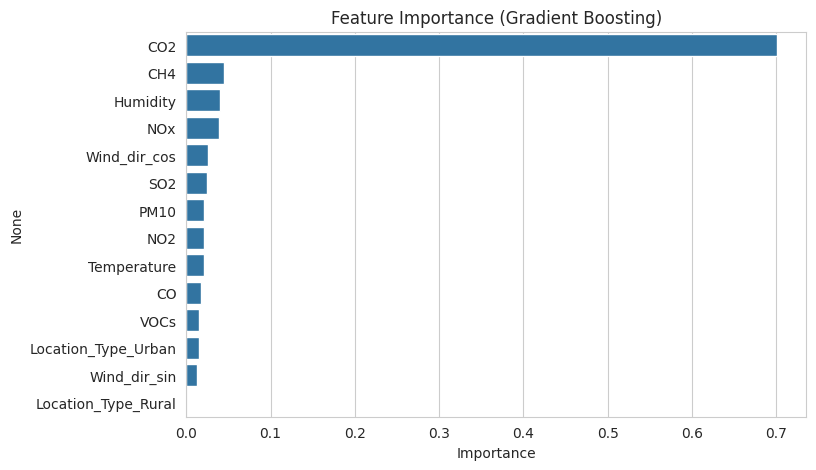

In [19]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title(f"Feature Importance ({best_name})")
plt.xlabel("Importance")
plt.show()


## Phase 13: Convert predicted PM2.5 into risk levels

The regression output (a raw PM2.5 number) is turned into a readable risk category, based on
standard PM2.5 breakpoints. This is the actual "risk forecasting" output of the project.

In [20]:
def pm25_to_risk(pm25):
    if pm25 <= 30:
        return "Good"
    elif pm25 <= 60:
        return "Moderate"
    elif pm25 <= 90:
        return "Poor"
    else:
        return "Severe"

risk_df = pd.DataFrame({
    "Actual_PM2.5": y_test.values,
    "Predicted_PM2.5": best_preds,
})
risk_df["Predicted_Risk"] = risk_df["Predicted_PM2.5"].apply(pm25_to_risk)
risk_df["Actual_Risk"] = risk_df["Actual_PM2.5"].apply(pm25_to_risk)

risk_df.head(10)


,Actual_PM2.5,Predicted_PM2.5,Predicted_Risk,Actual_Risk
0,26.548982,41.570991,Moderate,Good
1,35.961208,36.001952,Moderate,Moderate
2,34.236104,36.684501,Moderate,Moderate
3,84.233115,81.232423,Poor,Poor
4,57.061711,42.104385,Moderate,Moderate
5,43.500793,34.505404,Moderate,Moderate
6,16.124681,38.509486,Moderate,Good
7,43.770788,35.467841,Moderate,Moderate
8,76.624911,85.315082,Poor,Poor
9,55.669846,44.663417,Moderate,Moderate


## Conclusion

- Built a regression pipeline predicting PM2.5 from other pollutant and weather readings.
- Compared Linear Regression (baseline), Random Forest, Gradient Boosting, and XGBoost.
- Selected the best-performing model (by RMSE) among the three for further analysis - no
  hyperparameter tuning applied.
- Identified the most important features driving PM2.5 levels.
- Converted predictions into risk categories (Good / Moderate / Poor / Severe) to complete the
  "risk intelligence" goal of the project.
